In [1]:
from skimage.io import imread
import numpy as np
from scipy.io import loadmat
import scipy as sp
from matplotlib import pyplot as plt
import time

In [36]:
rootfolder = '.'


Useful function for plot the dictionary

In [37]:
def get_dictionary_img(D):
    M, N = D.shape
    p = int(round(np.sqrt(M)))
    nnn = int(np.ceil(np.sqrt(N)))
    bound = 2
    img = np.ones((nnn*p+bound*(nnn-1), nnn*p+bound*(nnn-1)))
    for i in range(N):
        m = np.mod(i, nnn)
        n = int((i-m)/nnn)
        m = m * p + bound * m
        n = n * p + bound * n
        atom = D[:, i].reshape((p, p))
        if atom.min() < atom.max():
            atom = (atom - atom.min()) / (atom.max() - atom.min())
        img[m: m + p, n: n + p] = atom

    return img

In [38]:
def soft_thresholding(x, lmbda):
    # perform soft thresholding of x
    return np.sign(x) * np.maximum(np.abs(x) - lmbda, 0)

def FISTA(s, D, lmbda, max_iter=10):
    MAX_ITER = max_iter
    TOL_DIST_X = 1e-6
    # initialize x
    x = np.zeros(D.shape[1])
    # initialize y
    y = x
    # initialize gamma
    gamma = 1
    distanceX = 1e10
    # initialize the list with all the estimates
    all_x = [x]
    alpha = 1 / np.max(np.linalg.eigvalsh(D.T @ D))
    cnt = 0
    while cnt < MAX_ITER and distanceX > TOL_DIST_X:
        # compute the gradient
        grad = D.T @ (D @ y - s)
        # compute the argument of the proximal operator
        z = y - alpha * grad
        # perform soft thresholding
        x = soft_thresholding(z, alpha * lmbda)
        # update gamma
        gamma_past = gamma
        gamma = (1 + np.sqrt(1 + 4 * gamma_past**2)) / 2
        # update y
        y = x + ((gamma - 1) / gamma_past) * (x - all_x[-1])
        # compute the stopping criteria
        distanceX = np.linalg.norm(all_x[-1] - x)
        # store the estimate
        all_x.append(x)
        cnt += 1
    return x

In [2]:
# MOD and IRLS Funciton
def IRLS(s, D, lmbda, x0=None, max_iter = 10):

    MAX_ITER = max_iter  
    TOL_DIST_X = 1e-10
    # initialization
    if x0 == None:
        x0 = D.T @ s
    distanceX = 1e10  # stopping criteria
    cnt = 0


    while cnt < MAX_ITER and distanceX > TOL_DIST_X:
        x = x0

        # compute the weight matrix
        W = np.diag(1/(np.abs(x)+ delta))

        # solve the weighted regularized LS system
        x_current = np.linalg.inv(D.T @ D + lmbda * W) @ D.T @ s
        distanceX = np.linalg.norm(x_current - x)

        # store the estimate
        x0 = x_current
        cnt = cnt + 1

        
    return x_current


#MOD
def mod(S,M, npatch, lmbda,N = 96, max_iter = 10, delta = 1e-6):
    

    X = np.ones((N, npatch))
    D = np.random.normal(size=(M,npatch))

    # normalize each column of D (zero mean and unit norm)
    # UPDATE D
    D = D - np.mean(D, axis = 0)

    for j in range(N):
        D[:,j] = D[:,j]/np.linalg.norm(D[:,j]) 
    
    for iter in range(max_iter):
        print(f"{iter} / {max_iter}")
        # perform the sparse coding for all the patches in S
        for n in range(npatch):
            print(f"-> {n}/{npatch}\n")
            s = S[:, n]
            x = IRLS(s, D, lmbda)
            X[:, n] = x

        # MOD update
        D = S @ X.T @ np.linalg.inv(X@X.T + delta * np.identity(N) )

        # normalize the column
        D = D / np.linalg.norm(D, axis=0,keepdims=True)
    return D

Set all the parameters for the anomaly detection

In [39]:
# patch size (tha patch is square)
p = 15

# number of patches in the training set for dictionary learning
npatch_dictionary = 10000

# number of patches to estimate the confidence region
npatch_region = 1000

# parameters for the dictionary learning using the KSVD
niter_dl = 10
natom = int(np.round(p**2*1.5))
L = 4

# regularization parameters for the l1 sparse coding
lmbda = 0.18

Construct the training and validation sets
------------------------------------------

In [40]:
# load the training image and rescale it in [0,1]
img = imread(f'{rootfolder}/data/img_normal.png') / 255
imsz = img.shape
# extract random patches from the image and store them in a matrices S, V
S = np.zeros((p**2, npatch_dictionary))
for i in range(npatch_dictionary):
    indexx = np.random.randint(imsz[0]-p)
    indexy = np.random.randint(imsz[1]-p)
    s = img[indexx:indexx+p, indexy:indexy+p] 
    S[:, i] = s.reshape(-1)
V = np.zeros((p**2, npatch_region))
for i in range(npatch_region):
    indexx = np.random.randint(imsz[0]-p)
    indexy = np.random.randint(imsz[1]-p)
    s = img[indexx:indexx+p, indexy:indexy+p] 
    V[:, i] = s.reshape(-1)

Dictionary Learning
-------------------
Perform preprocessing on the patches in $S$

In [41]:
# PREPROCESSING: exclude black patches from S
v = np.median(S, axis=0)
S = S[:,v > 0.06]

In [42]:
# PREPROCESSING: remove the mean from each patch
S = S- np.mean(S, axis=0)


Perform dictionary learning via KSVD or MOD

In [ ]:
#D = mod(S,M, npatch_dictionary, lmbda)

# or load a precomputed dictionary
D = loadmat(f'{rootfolder}/data/dict_anom_det.mat')['D']

Show the learned dictionary

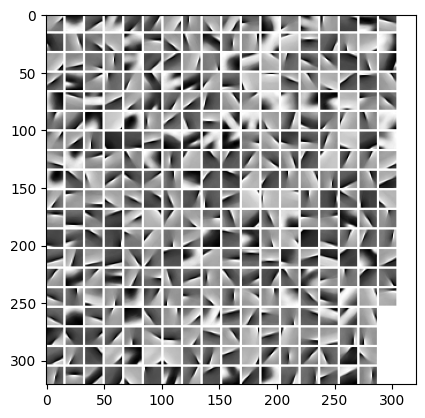

In [44]:
img_dict = get_dictionary_img(D)
plt.imshow(img_dict, cmap='gray')
plt.show()

## Confidence region estimation / density estimation

In [45]:
# PREPROCESSING: exclude black patches
v = np.median(V, axis=0)
V = V[:,v > 0.06]

In [46]:
# PREPROCESSING: remove the mean from each patch
V = V - np.mean(V, axis=0)

In [47]:
# sparse coding of each patch in V
X = np.zeros((natom, npatch_region))
for i in range(V.shape[1]):
    X[:, i] = FISTA(V[:,i], D, 0.5)



In [48]:
# computing the anomaly indicators (l1 norm, reconstruction error) for each
# patch in V

A = np.zeros((2, V.shape[1]))     # each column contains the values of the anomaly_scores for a patch

for i in range(V.shape[1]):
    A[:,i] = np.array([np.linalg.norm(V[:,i]- D @ X[:,i]), np.linalg.norm(X[:,i], ord=1)])

# Estimation of mean and covariance
mu = np.mean(A, axis=1)
Sigma = np.cov(A)


In [49]:
# estimation of the threshold that gives the desired false positive rate
# using the patches in V

FPR_target = 0.1

# compute the Mahalanobis distance for each indicator vector in A
mahal_dist = np.zeros(V.shape[1])
for i in range(A.shape[1]):
    mahal_dist[i] = (A[:,i] - mu) @ np.linalg.inv(Sigma) @ (A[:,i]-mu)

# set the threshold
threshold = np.quantile(mahal_dist, 1 - FPR_target)


## Test phase

In [50]:
# load the test image
img_test = imread(f'{rootfolder}/data/img_anom.png') / 255

imsz = img_test.shape

STEP = 7
# initialize the estimated image
heatmap = np.zeros_like(img)

# initialize the weight matrix
weights = np.zeros_like(img)

In [52]:
for i in range(0, imsz[0] - p + 1, STEP):
    for j in range(0, imsz[1] - p + 1, STEP):
        # extrach the patch with the top left corner at pixel (ii, jj)
        s = img_test[i:i+p, j:j+p]

        # if the median of s is to small set the anomaly score to 0:
        if np.median(s) <= 0.06:
            score = 0
        else:
            # subratct the mean to the patch
            s = s - np.mean(s)
            s = s.reshape(-1)
            # perform the sparse coding
            x = FISTA(s, D, 0.5)

            # compute the anomaly indicators vector
            a = np.array([np.linalg.norm(s- D @ x), np.linalg.norm(x, ord=1)])

            # compute the anomaly score
            score = (a - mu) @ np.linalg.inv(Sigma) @ (a-mu)

        # update the heatmap
        heatmap[i:i+p, j:j+p] += score

        # update the weight matrix
        weights[i:i+p, j:j+p] += 1


In [53]:
# normalize the heatmap
heatmap = heatmap/weights

/tmp/ipykernel_5647/3148978227.py:2: RuntimeWarning: invalid value encountered in divide
  heatmap = heatmap/weights


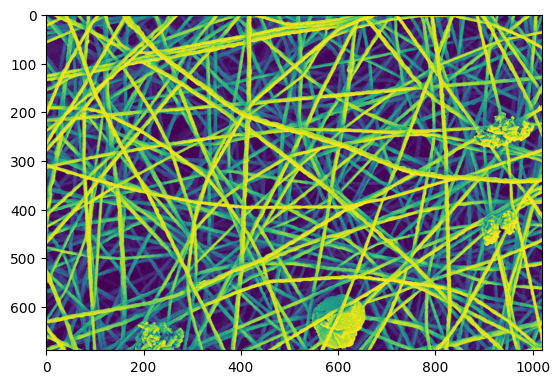

In [59]:
plt.imshow(img_test)

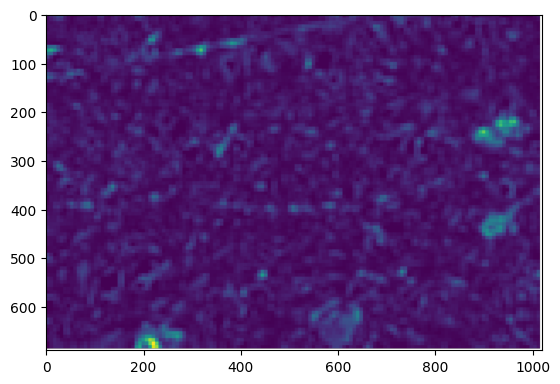

In [54]:
# plot the heatmap
plt.imshow(heatmap)

In [60]:
# build the detection mask, that has the same size of the test image
# each pixel in the mask has value 1 if the corresponding patch has been
# detected as anomalous, otherwise it has value 0
mask = heatmap > threshold


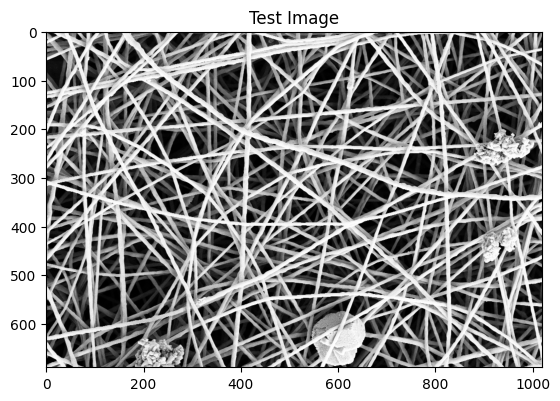

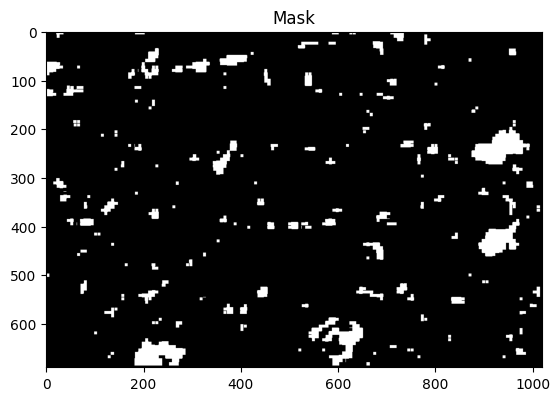

In [61]:
## show the results
plt.figure(3), plt.imshow(img_test, cmap='gray'), plt.title('Test Image')
plt.figure(4), plt.imshow(mask, cmap='gray'), plt.title('Mask')
plt.show()

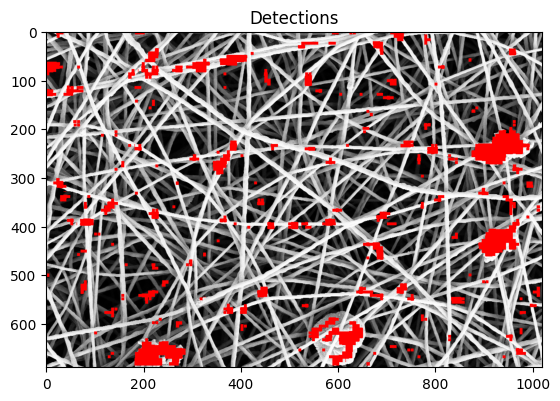

In [62]:
# combine the mask and the test image
img_color = np.zeros([img_test.shape[0], img_test.shape[1], 3])
img_temp = img_test.copy()
img_temp[mask > 0] = 1
img_color[:,:,0] = img_temp
img_temp = img_test.copy()
img_temp[mask > 0] = 0
img_color[:,:,1] = img_temp
img_temp = img_test.copy()
img_temp[mask > 0] = 0
img_color[:,:,2] = img_temp

plt.figure(5), plt.imshow(img_color), plt.title('Detections')
plt.show()